In [1]:
#install required data
#!pip install hecdss --break-system-packages

In [2]:
#import required data
import pandas as pd
from hecdss import HecDss
from datetime import datetime

In [3]:
#open the observed data, select sheet and clip columns
dfRaw = pd.read_csv('../Xls/flowMiamiRiver_s00046_n03.csv')
#dfRaw = dfRaw[['SW2','flowm3s']]
dfRaw.head()

,SW2,ElevRaw,waterStage,flowm3s
0,2023-01-01 00:00:00,145.262786,148.662786,24.888343
1,2023-01-01 01:00:00,145.273004,148.673004,25.340926
2,2023-01-01 02:00:00,145.292494,148.692494,25.737968
3,2023-01-01 03:00:00,145.302354,148.702354,26.186608
4,2023-01-01 04:00:00,145.318458,148.718458,26.926004


In [4]:
dfRaw.tail()

,SW2,ElevRaw,waterStage,flowm3s
1435,2023-03-01 19:00:00,146.202409,149.602409,74.585648
1436,2023-03-01 20:00:00,146.188216,149.588216,73.492419
1437,2023-03-01 21:00:00,146.185936,149.585936,73.317445
1438,2023-03-01 22:00:00,146.179716,149.579716,72.840881
1439,2023-03-01 23:00:00,146.147194,149.547194,70.369299


In [5]:
#import data on a correct format
dfHeads = pd.DataFrame()
dfHeads.index=pd.to_datetime(dfRaw['SW2'])
dfHeads['Flow m3/s'] = pd.to_numeric(dfRaw['flowm3s']).to_list()
dfHeads['Factor'] = 0.98
dfHeads['Flow m3/s x Factor'] = dfHeads['Flow m3/s'] * dfHeads['Factor']
dfHeads.head()

,Flow m3/s,Factor,Flow m3/s x Factor
SW2,,,
2023-01-01 00:00:00,24.888343,0.98,24.390576
2023-01-01 01:00:00,25.340926,0.98,24.834107
2023-01-01 02:00:00,25.737968,0.98,25.223209
2023-01-01 03:00:00,26.186608,0.98,25.662876
2023-01-01 04:00:00,26.926004,0.98,26.387484


<AxesSubplot: xlabel='SW2'>

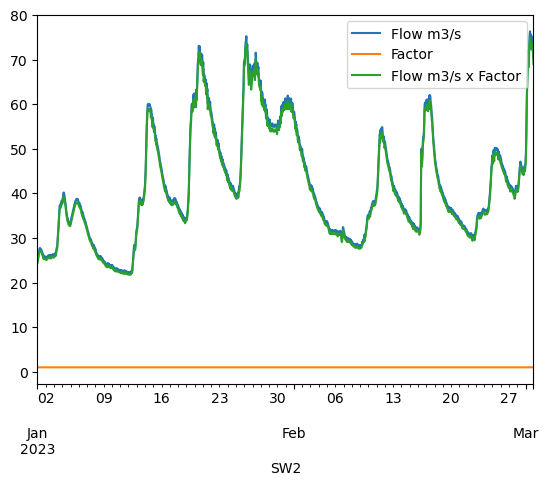

In [6]:
#plot histogram
dfHeads.plot()

In [7]:
from pydsstools.core import TimeSeriesContainer, UNDEFINED
from pydsstools.heclib.dss import HecDss

# 2. Extract arrays
times = dfHeads.index.tolist()
#values = dfHeads['Flow m3/s'].astype(float).tolist()
values = dfHeads['Flow m3/s x Factor'].astype(float).tolist()

dss_file = "../Xls/riverFlowSw2_s00046_n03_f0_98.dss"
pathname = "/THEISNASH/SW1/FLOW//1HOUR/OBSERVED/"

with HecDss.Open(dss_file) as fid:
    count = len(values)
    interval = 1  # positive = regular time series

    tsc = TimeSeriesContainer(pathname, count, interval)
    tsc.start_time = times[0]
    tsc.data_units = "CMS"
    tsc.data_type = "INST-VAL"
    tsc.tzid = "UTC"
    tsc.values = values  # UNDEFINED marks missing data

    fid.put_ts(tsc)

22:41:34.697      -----DSS---zopen   New file opened,  File: ../Xls/riverFlowSw2_s00046_n03_f0_98.dss
22:41:34.697                         Handle 71;  Process: 91158;  DSS Version:  7-IV
22:41:34.697                         Single-user advisory access mode
22:41:34.723 -----DSS--- zwrite  Handle 71;  Version 1:  /THEISNASH/SW1/FLOW/01Dec2022/1Hour/OBSERVED/
22:41:34.738 -----DSS--- zwrite  Handle 71;  Version 1:  /THEISNASH/SW1/FLOW/01Jan2023/1Hour/OBSERVED/
22:41:34.754 -----DSS--- zwrite  Handle 71;  Version 1:  /THEISNASH/SW1/FLOW/01Feb2023/1Hour/OBSERVED/
22:41:34.772 -----DSS--- zwrite  Handle 71;  Version 1:  /THEISNASH/SW1/FLOW/01Mar2023/1Hour/OBSERVED/
22:41:34.781      -----DSS---zclose  Handle 71;  Process: 91158;  File: ../Xls/riverFlowSw2_s00046_n03_f0_98.dss
22:41:34.781                         Number records:         4
22:41:34.781                         File size:              16690  64-bit words
22:41:34.781                         File size:              130 Kb;  0 Mb

In [8]:
# # 2. Extract arrays
# times = dfHeads.index.tolist()
# values = dfHeads['Flow m3/s'].astype(float).tolist()

# dss_file = "../Xls/riverStageSw2.dss"
# pathname = "/THEISNASH/SW2/STAGE//1HOUR/OBSERVED/"

# with HecDss.Open(dss_file) as fid:
#     count = len(values)
#     interval = 1  # positive = regular time series

#     tsc = TimeSeriesContainer(pathname, count, interval)
#     tsc.start_time = times[0]
#     tsc.data_units = "METERS"
#     tsc.data_type = "INST"
#     tsc.tzid = "UTC"
#     tsc.values = values  # UNDEFINED marks missing data

#     fid.put_ts(tsc)